# Sequence-to-Sequence Models with Attention

## 1. Introduction

In this notebook, we'll explore **sequence-to-sequence (seq2seq)** models - a fundamental architecture for transforming one sequence into another. Think machine translation (English → French), text summarization (long text → short summary), or even simple tasks like reversing a string.

### What we'll learn:
1. The **encoder-decoder architecture** - how to compress a sequence into a fixed representation and decode it
2. The **bottleneck problem** - why naive seq2seq struggles with long sequences
3. The **attention mechanism** - how to let the decoder "look back" at the input sequence
4. **Alignment visualization** - seeing what the model focuses on at each step

### Why this matters:
The attention mechanism revolutionized deep learning and led directly to Transformers (GPT, BERT, etc.). Understanding attention in the seq2seq context provides the intuition needed for modern architectures.

### Our task:
We'll train a model to **reverse strings**. Simple, but perfect for understanding the mechanics:
- Input: "hello" → Output: "olleh"
- Input: "pytorch" → Output: "hcrotpy"

## 2. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
import string
from tqdm.auto import tqdm

from aiml_notebooks import set_seed, get_device

# Auto-reload for development
%load_ext autoreload
%autoreload 2

### Set random seed for reproducibility

In [2]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using CPU
Using device: cpu


## 3. Dataset Creation

We'll create a synthetic dataset of random strings and their reversals. This lets us control the complexity and focus on the architecture.

### Define special tokens

Sequence models need special tokens:
- **PAD**: Padding token (make sequences same length)
- **SOS**: Start-of-sequence token (tells decoder to start generating)
- **EOS**: End-of-sequence token (tells decoder to stop)

In [3]:
# Vocabulary: lowercase letters + special tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

chars = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + list(string.ascii_lowercase)
char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

vocab_size = len(chars)
PAD_IDX = char_to_idx[PAD_TOKEN]
SOS_IDX = char_to_idx[SOS_TOKEN]
EOS_IDX = char_to_idx[EOS_TOKEN]

print(f"Vocabulary size: {vocab_size}")
print(f"Special tokens: PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}")
print(f"Sample vocab: {chars[:10]}...")

Vocabulary size: 29
Special tokens: PAD=0, SOS=1, EOS=2
Sample vocab: ['<PAD>', '<SOS>', '<EOS>', 'a', 'b', 'c', 'd', 'e', 'f', 'g']...


### Generate random strings

We'll create strings of varying lengths (3-10 characters) to make the model robust.

In [4]:
def generate_random_string(min_len=3, max_len=10):
    """Generate a random lowercase string."""
    length = random.randint(min_len, max_len)
    return ''.join(random.choice(string.ascii_lowercase) for _ in range(length))

def generate_dataset(num_samples=10000, min_len=3, max_len=10):
    """Generate pairs of (input_string, reversed_string)."""
    dataset = []
    for _ in range(num_samples):
        s = generate_random_string(min_len, max_len)
        reversed_s = s[::-1]
        dataset.append((s, reversed_s))
    return dataset

# Generate training and validation data
train_data = generate_dataset(10000, min_len=3, max_len=10)
val_data = generate_dataset(1000, min_len=3, max_len=10)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"\nExample pairs:")
for i in range(5):
    inp, out = train_data[i]
    print(f"  '{inp}' → '{out}'")

Training samples: 10000
Validation samples: 1000

Example pairs:
  'axih' → 'hixa'
  'exdvxr' → 'rxvdxe'
  'snba' → 'abns'
  'ghqt' → 'tqhg'
  'rgw' → 'wgr'


### Create PyTorch Dataset

We need to convert strings to token indices and handle padding.

In [5]:
class Seq2SeqDataset(Dataset):
    def __init__(self, data, char_to_idx, max_len=None):
        self.data = data
        self.char_to_idx = char_to_idx
        # Calculate max length if not provided
        if max_len is None:
            max_len = max(len(inp) for inp, _ in data)
        self.max_len = max_len
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        input_str, target_str = self.data[idx]
        
        # Convert to indices
        input_indices = [self.char_to_idx[ch] for ch in input_str]
        # Target needs SOS at start, EOS at end
        target_indices = [SOS_IDX] + [self.char_to_idx[ch] for ch in target_str] + [EOS_IDX]
        
        return {
            'input': torch.tensor(input_indices, dtype=torch.long),
            'target': torch.tensor(target_indices, dtype=torch.long),
            'input_str': input_str,
            'target_str': target_str
        }

train_dataset = Seq2SeqDataset(train_data, char_to_idx)
val_dataset = Seq2SeqDataset(val_data, char_to_idx, max_len=train_dataset.max_len)

print(f"Max sequence length: {train_dataset.max_len}")
sample = train_dataset[0]
print(f"\nSample:")
print(f"  Input string: {sample['input_str']}")
print(f"  Input indices: {sample['input'].tolist()}")
print(f"  Target string: {sample['target_str']}")
print(f"  Target indices: {sample['target'].tolist()}")

Max sequence length: 10

Sample:
  Input string: axih
  Input indices: [3, 26, 11, 10]
  Target string: hixa
  Target indices: [1, 10, 11, 26, 3, 2]


### Create DataLoaders with padding

Batches need sequences of the same length, so we pad shorter sequences.

In [6]:
def collate_fn(batch):
    """Collate function to pad sequences to the same length in a batch."""
    # Separate inputs and targets
    inputs = [item['input'] for item in batch]
    targets = [item['target'] for item in batch]
    
    # Pad sequences
    inputs_padded = nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=PAD_IDX)
    targets_padded = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=PAD_IDX)
    
    return {
        'input': inputs_padded,
        'target': targets_padded,
        'input_str': [item['input_str'] for item in batch],
        'target_str': [item['target_str'] for item in batch]
    }

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Check a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Input: {batch['input'].shape}  # (batch_size, seq_len)")
print(f"  Target: {batch['target'].shape}  # (batch_size, seq_len + 2)  [+2 for SOS/EOS]")

Training batches: 79
Validation batches: 8

Batch shapes:
  Input: torch.Size([128, 10])  # (batch_size, seq_len)
  Target: torch.Size([128, 12])  # (batch_size, seq_len + 2)  [+2 for SOS/EOS]


## 4. Encoder-Decoder Architecture (Without Attention)

Let's first build a basic seq2seq model **without attention** to understand the bottleneck problem.

### The Architecture:
1. **Encoder**: Reads the input sequence and produces a **fixed-size context vector**
2. **Decoder**: Uses the context vector to generate the output sequence

### The Problem:
The entire input must be compressed into a single fixed-size vector. For long sequences, information gets lost!

### Encoder: Compress input into context vector

The encoder is an RNN (we'll use GRU) that processes the input sequence and returns its final hidden state as the "context".

In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        outputs, hidden = self.gru(embedded)  # outputs: (batch, seq_len, hidden_dim)
                                                # hidden: (1, batch, hidden_dim)
        return outputs, hidden

# Test encoder
encoder = Encoder(vocab_size, embedding_dim=32, hidden_dim=64)
test_input = batch['input'][:4]  # Take 4 samples
outputs, hidden = encoder(test_input)
print(f"Encoder outputs shape: {outputs.shape}  # All hidden states")
print(f"Encoder hidden shape: {hidden.shape}   # Final hidden state (context vector)")

Encoder outputs shape: torch.Size([4, 10, 64])  # All hidden states
Encoder hidden shape: torch.Size([1, 4, 64])   # Final hidden state (context vector)


### Decoder: Generate output from context

The decoder is also an RNN that:
1. Starts with the encoder's final hidden state
2. Generates output tokens one at a time
3. Uses its own previous output as the next input (autoregressive)

In [8]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden):
        # x: (batch, 1) - single token
        # hidden: (1, batch, hidden_dim) - from encoder or previous step
        embedded = self.embedding(x)  # (batch, 1, embedding_dim)
        output, hidden = self.gru(embedded, hidden)  # output: (batch, 1, hidden_dim)
        prediction = self.fc(output.squeeze(1))  # (batch, vocab_size)
        return prediction, hidden

# Test decoder
decoder = Decoder(vocab_size, embedding_dim=32, hidden_dim=64)
test_token = torch.tensor([[SOS_IDX]] * 4)  # Start with SOS for 4 samples
prediction, new_hidden = decoder(test_token, hidden)
print(f"Decoder prediction shape: {prediction.shape}  # Logits over vocabulary")
print(f"Decoder hidden shape: {new_hidden.shape}")

Decoder prediction shape: torch.Size([4, 29])  # Logits over vocabulary
Decoder hidden shape: torch.Size([1, 4, 64])


### Seq2Seq Model: Putting encoder and decoder together

The complete model:
1. Encode input → context vector
2. Decode context → output sequence

In [9]:
class Seq2Seq(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(vocab_size, embedding_dim, hidden_dim)
        self.decoder = Decoder(vocab_size, embedding_dim, hidden_dim)
        
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: (batch, src_len)
        # trg: (batch, trg_len)
        batch_size = src.size(0)
        trg_len = trg.size(1)
        src_len = src.size(1)
        
        # Encode
        _, hidden = self.encoder(src)
        
        # Prepare decoder
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(src.device)
        input_token = trg[:, 0].unsqueeze(1)  # Start with SOS
        
        # Decode step by step
        for t in range(1, trg_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t] = output
            
            # Teacher forcing: use ground truth or prediction?
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1
        
        # Return dummy attention for compatibility with training function
        dummy_attention = torch.zeros(batch_size, trg_len, src_len).to(src.device)
        return outputs, dummy_attention

# Test model
model = Seq2Seq(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
test_src = batch['input'][:4].to(device)
test_trg = batch['target'][:4].to(device)
test_outputs, test_attn = model(test_src, test_trg)
print(f"Model output shape: {test_outputs.shape}  # (batch, trg_len, vocab_size)")
print(f"Dummy attention shape: {test_attn.shape}  # (batch, trg_len, src_len)")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([4, 12, 29])  # (batch, trg_len, vocab_size)
Dummy attention shape: torch.Size([4, 12, 10])  # (batch, trg_len, src_len)

Total parameters: 41,373


### Key Insight: The Bottleneck Problem

The encoder's **final hidden state** must capture the entire input sequence. This single vector becomes a bottleneck:
- **Short sequences**: Works reasonably well
- **Long sequences**: Information gets lost, performance degrades

**Solution**: Attention mechanism - let the decoder "look back" at all encoder hidden states!

## 5. Attention Mechanism

The **attention mechanism** solves the bottleneck problem by allowing the decoder to access all encoder hidden states, not just the final one.

### Core Idea:
At each decoding step, compute a weighted average of all encoder hidden states. The weights represent "how much to attend to" each input position.

### The Math:

Given:
- Encoder outputs: $h_1, h_2, ..., h_n$ (all hidden states)
- Current decoder state: $s_t$

1. **Compute alignment scores**: How relevant is each encoder state?
   $$e_{t,i} = \text{score}(s_t, h_i)$$
   
2. **Normalize to get attention weights** (using softmax):
   $$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}$$
   
3. **Compute context vector** (weighted sum):
   $$c_t = \sum_i \alpha_{t,i} h_i$$
   
The context vector $c_t$ is then used (along with $s_t$) to generate the output.

### Attention Module Implementation

We'll use **additive attention** (Bahdanau attention), which scores using a small neural network.

In [10]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Alignment model: learns to score relevance
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
        
    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden_dim) - current decoder state
        # encoder_outputs: (batch, src_len, hidden_dim) - all encoder states
        
        batch_size = encoder_outputs.size(0)
        src_len = encoder_outputs.size(1)
        
        # Repeat decoder state for each encoder position
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch, src_len, hidden_dim)
        
        # Concatenate and compute scores
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))  # (batch, src_len, hidden_dim)
        attention_scores = self.v(energy).squeeze(2)  # (batch, src_len)
        
        # Normalize to get attention weights
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch, src_len)
        
        # Compute context vector (weighted sum)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)  # (batch, 1, hidden_dim)
        context = context.squeeze(1)  # (batch, hidden_dim)
        
        return context, attention_weights

# Test attention
attention = Attention(hidden_dim=64)
test_hidden = torch.randn(4, 64)  # Batch of 4, hidden_dim=64
test_encoder_outputs = torch.randn(4, 10, 64)  # Batch of 4, seq_len=10, hidden_dim=64
context, weights = attention(test_hidden, test_encoder_outputs)
print(f"Context vector shape: {context.shape}  # (batch, hidden_dim)")
print(f"Attention weights shape: {weights.shape}  # (batch, src_len)")
print(f"\nAttention weights sum: {weights[0].sum().item():.4f}  # Should be 1.0")
print(f"Sample attention weights: {weights[0].tolist()[:5]}")

Context vector shape: torch.Size([4, 64])  # (batch, hidden_dim)
Attention weights shape: torch.Size([4, 10])  # (batch, src_len)

Attention weights sum: 1.0000  # Should be 1.0
Sample attention weights: [0.0888151302933693, 0.13658368587493896, 0.07873561978340149, 0.080973781645298, 0.10044555366039276]


### Decoder with Attention

Now we modify the decoder to use attention at each step.

In [11]:
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.attention = Attention(hidden_dim)
        # Input is now embedding + context vector
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden, encoder_outputs):
        # x: (batch, 1) - single token
        # hidden: (1, batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)
        
        embedded = self.embedding(x)  # (batch, 1, embedding_dim)
        
        # Compute attention
        context, attention_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        context = context.unsqueeze(1)  # (batch, 1, hidden_dim)
        
        # Concatenate embedding and context
        rnn_input = torch.cat((embedded, context), dim=2)  # (batch, 1, embedding_dim + hidden_dim)
        
        # Generate output
        output, hidden = self.gru(rnn_input, hidden)
        prediction = self.fc(output.squeeze(1))  # (batch, vocab_size)
        
        return prediction, hidden, attention_weights

# Test attention decoder
attn_decoder = AttentionDecoder(vocab_size, embedding_dim=32, hidden_dim=64)
test_token = torch.tensor([[SOS_IDX]] * 4)
test_hidden = torch.randn(1, 4, 64)
test_enc_outputs = torch.randn(4, 10, 64)
prediction, new_hidden, attn_weights = attn_decoder(test_token, test_hidden, test_enc_outputs)
print(f"Prediction shape: {prediction.shape}")
print(f"Hidden shape: {new_hidden.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

Prediction shape: torch.Size([4, 29])
Hidden shape: torch.Size([1, 4, 64])
Attention weights shape: torch.Size([4, 10])


### Seq2Seq with Attention

Complete model combining encoder and attention-based decoder.

In [12]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(vocab_size, embedding_dim, hidden_dim)
        self.decoder = AttentionDecoder(vocab_size, embedding_dim, hidden_dim)
        
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: (batch, src_len)
        # trg: (batch, trg_len)
        batch_size = src.size(0)
        trg_len = trg.size(1)
        
        # Encode - keep ALL hidden states
        encoder_outputs, hidden = self.encoder(src)
        
        # Prepare decoder
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(src.device)
        attentions = torch.zeros(batch_size, trg_len, src.size(1)).to(src.device)
        input_token = trg[:, 0].unsqueeze(1)  # Start with SOS
        
        # Decode step by step
        for t in range(1, trg_len):
            output, hidden, attention_weights = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t] = output
            attentions[:, t] = attention_weights
            
            # Teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1
            
        return outputs, attentions

# Create model
model_attn = Seq2SeqAttention(vocab_size, embedding_dim=64, hidden_dim=128).to(device)
print(f"Total parameters: {sum(p.numel() for p in model_attn.parameters()):,}")

# Test forward pass
test_src = batch['input'][:4].to(device)
test_trg = batch['target'][:4].to(device)
test_outputs, test_attentions = model_attn(test_src, test_trg)
print(f"\nOutput shape: {test_outputs.shape}")
print(f"Attention shape: {test_attentions.shape}  # (batch, trg_len, src_len)")

Total parameters: 238,621

Output shape: torch.Size([4, 12, 29])
Attention shape: torch.Size([4, 12, 10])  # (batch, trg_len, src_len)


## 6. Training

Now let's train the model with attention.

### Define training function

In [13]:
def train_epoch(model, loader, optimizer, criterion, device, teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0
    
    for batch in tqdm(loader, desc="Training", leave=False):
        src = batch['input'].to(device)
        trg = batch['target'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        output, _ = model(src, trg, teacher_forcing_ratio)
        
        # Reshape for loss calculation
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)  # Skip SOS token
        trg = trg[:, 1:].reshape(-1)  # Skip SOS token
        
        # Calculate loss
        loss = criterion(output, trg)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        epoch_loss += loss.item()
    
    return epoch_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            src = batch['input'].to(device)
            trg = batch['target'].to(device)
            
            # No teacher forcing during evaluation
            output, _ = model(src, trg, teacher_forcing_ratio=0.0)
            
            # Reshape for loss
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    
    return epoch_loss / len(loader)

### Train the model

We'll train for several epochs, gradually reducing teacher forcing to make the model more robust.

In [14]:
# Setup
model_attn = Seq2SeqAttention(vocab_size, embedding_dim=64, hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model_attn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Training loop
num_epochs = 15
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Decay teacher forcing ratio
    teacher_forcing_ratio = max(0.5 - epoch * 0.03, 0.0)
    
    train_loss = train_epoch(model_attn, train_loader, optimizer, criterion, device, teacher_forcing_ratio)
    val_loss = evaluate(model_attn, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | TF Ratio: {teacher_forcing_ratio:.2f}")

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 2.7020 | Val Loss: 2.0727 | TF Ratio: 0.50


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.0695 | Val Loss: 0.0135 | TF Ratio: 0.11


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.0562 | Val Loss: 0.0813 | TF Ratio: 0.08


### Visualize training progress

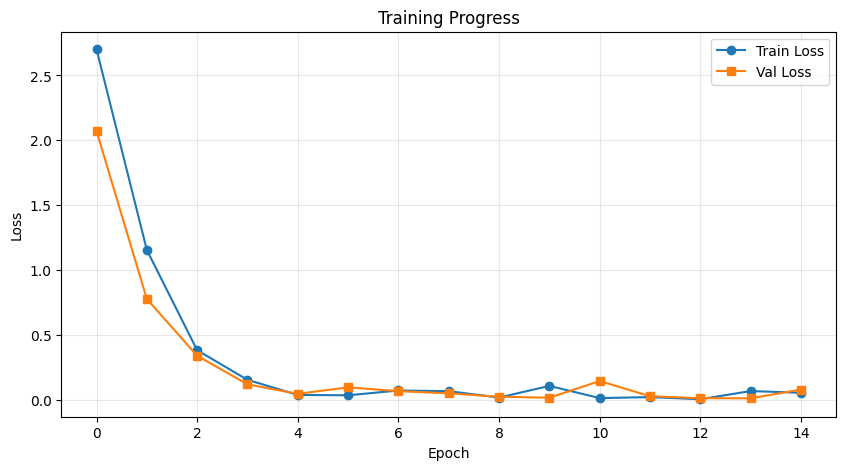


Final Training Loss: 0.0562
Final Validation Loss: 0.0813


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

## 7. Inference and Evaluation

Let's see how well the model reverses strings!

### Inference function

Generate predictions for new inputs.

In [16]:
def predict(model, input_str, max_len=20):
    """Generate output sequence for a given input string."""
    model.eval()
    
    with torch.no_grad():
        # Convert input to indices
        input_indices = [char_to_idx[ch] for ch in input_str]
        src = torch.tensor([input_indices]).to(device)  # (1, src_len)
        
        # Encode
        encoder_outputs, hidden = model_attn.encoder(src)
        
        # Decode step by step
        input_token = torch.tensor([[SOS_IDX]]).to(device)
        output_indices = []
        attention_weights_list = []
        
        for _ in range(max_len):
            output, hidden, attention_weights = model_attn.decoder(input_token, hidden, encoder_outputs)
            predicted_token = output.argmax(1).item()
            
            if predicted_token == EOS_IDX:
                break
                
            output_indices.append(predicted_token)
            attention_weights_list.append(attention_weights.cpu().numpy())
            input_token = torch.tensor([[predicted_token]]).to(device)
        
        # Convert indices to string
        output_str = ''.join([idx_to_char[idx] for idx in output_indices])
        attention_matrix = np.array(attention_weights_list).squeeze()
        
        return output_str, attention_matrix

### Test on examples

In [17]:
test_strings = [
    "hello",
    "pytorch",
    "attention",
    "ai",
    "transformer",
]

print("Model Predictions:\n")
for test_str in test_strings:
    predicted, _ = predict(model_attn, test_str)
    expected = test_str[::-1]
    correct = "✓" if predicted == expected else "✗"
    print(f"{correct} Input: '{test_str:12s}' → Predicted: '{predicted:12s}' (Expected: '{expected}')")

Model Predictions:

✗ Input: 'hello       ' → Predicted: 'oloolleh    ' (Expected: 'olleh')
✗ Input: 'pytorch     ' → Predicted: 'hhcrrotyp   ' (Expected: 'hcrotyp')
✓ Input: 'attention   ' → Predicted: 'noitnetta   ' (Expected: 'noitnetta')
✗ Input: 'ai          ' → Predicted: 'iaiiia      ' (Expected: 'ia')
✗ Input: 'transformer ' → Predicted: 'rerofsnart  ' (Expected: 'remrofsnart')


### Calculate accuracy on validation set

In [18]:
def calculate_accuracy(model, dataset, num_samples=100):
    """Calculate exact match accuracy."""
    correct = 0
    
    for i in range(min(num_samples, len(dataset))):
        input_str = dataset.data[i][0]
        expected = dataset.data[i][1]
        predicted, _ = predict(model, input_str)
        
        if predicted == expected:
            correct += 1
    
    return correct / min(num_samples, len(dataset))

val_accuracy = calculate_accuracy(model_attn, val_dataset, num_samples=100)
print(f"\nValidation Accuracy (100 samples): {val_accuracy*100:.1f}%")


Validation Accuracy (100 samples): 19.0%


## 8. Attention Visualization

The most powerful aspect of attention: we can **visualize what the model focuses on**!

The attention weights form an **alignment matrix** showing which input positions the model attends to when generating each output token.

### Visualize attention weights

In [19]:
def visualize_attention(input_str, attention_matrix):
    """Create a heatmap of attention weights."""
    predicted_str, _ = predict(model_attn, input_str)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot heatmap
    im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')
    
    # Set ticks
    ax.set_xticks(np.arange(len(input_str)))
    ax.set_yticks(np.arange(len(predicted_str)))
    ax.set_xticklabels(list(input_str))
    ax.set_yticklabels(list(predicted_str))
    
    # Labels
    ax.set_xlabel('Input Sequence', fontsize=12)
    ax.set_ylabel('Output Sequence', fontsize=12)
    ax.set_title(f'Attention Alignment: "{input_str}" → "{predicted_str}"', fontsize=14, pad=20)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attention Weight', rotation=270, labelpad=20)
    
    # Annotate cells with values
    for i in range(len(predicted_str)):
        for j in range(len(input_str)):
            text = ax.text(j, i, f'{attention_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    plt.tight_layout()
    plt.show()

### Visualize attention for several examples

Notice how the attention weights form a **diagonal pattern** - when generating the $i$-th output character, the model attends most to the corresponding input position. This is exactly what we'd expect for string reversal!


Input: 'hello' → Output: 'oloolleh'


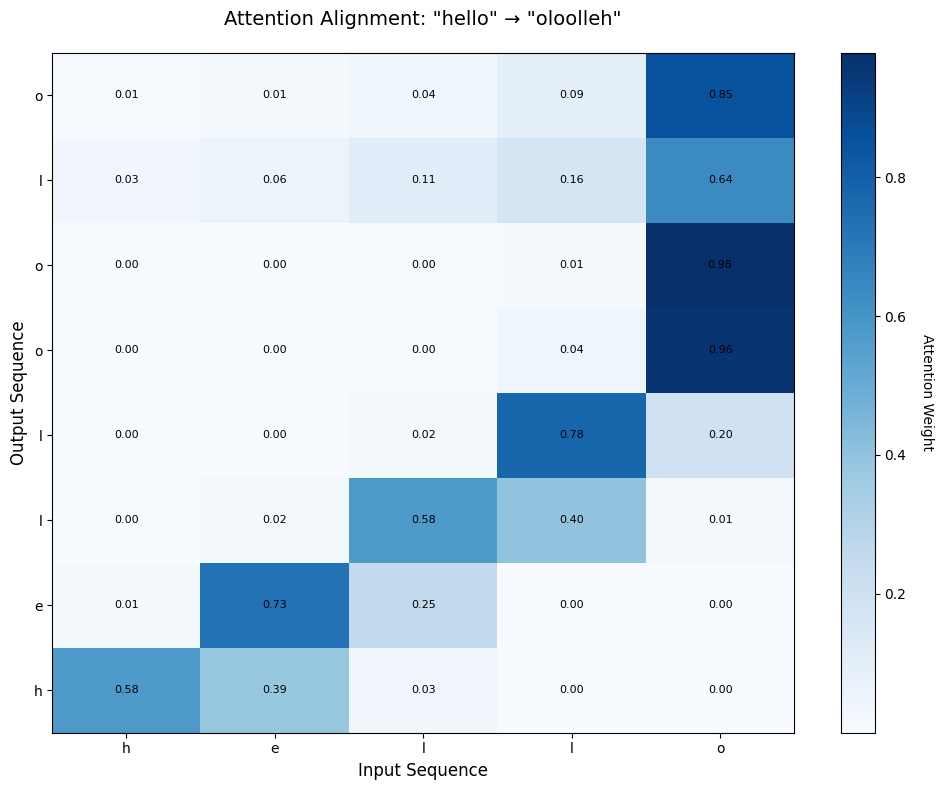


Input: 'pytorch' → Output: 'hhcrrotyp'


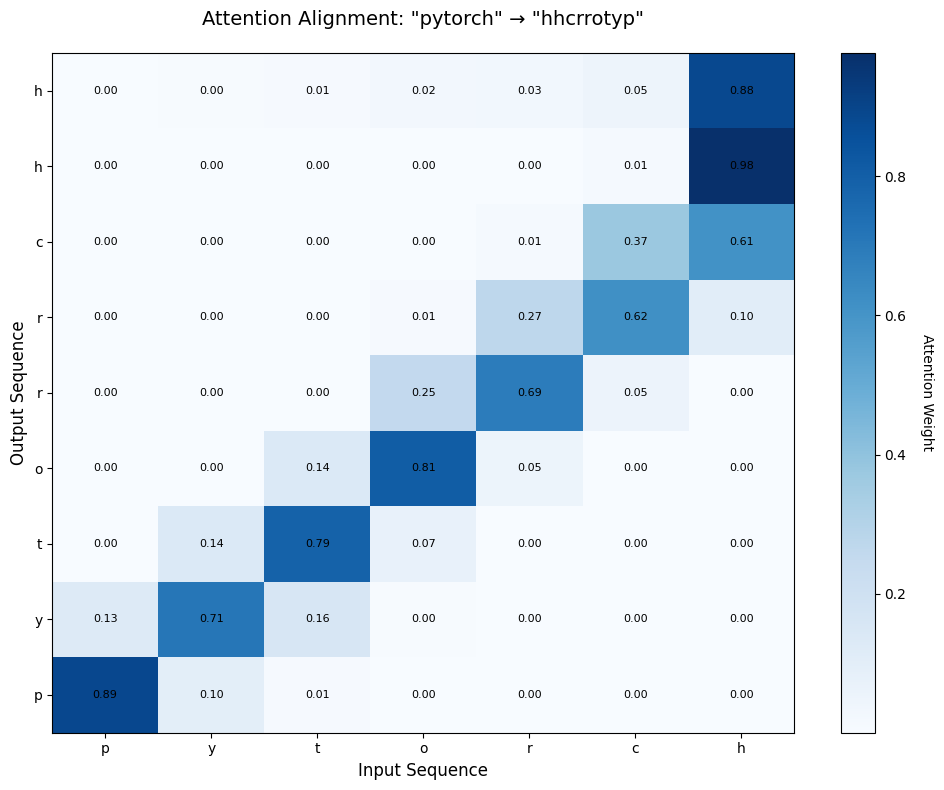


Input: 'attention' → Output: 'noitnetta'


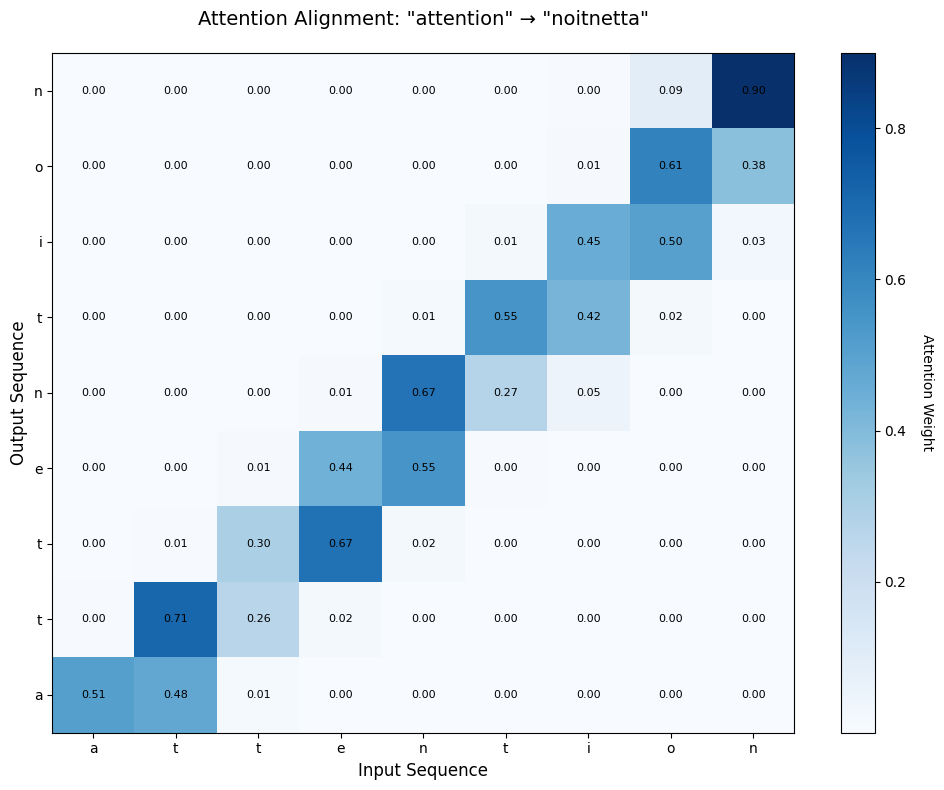

In [20]:
# Visualize attention for different examples
examples = ["hello", "pytorch", "attention"]

for example in examples:
    predicted, attention_matrix = predict(model_attn, example)
    print(f"\nInput: '{example}' → Output: '{predicted}'")
    visualize_attention(example, attention_matrix)

### Key Insight: Attention is Interpretable

The attention weights show us **exactly what the model is doing**:
- For string reversal, we see a clear reverse diagonal pattern
- For translation, we'd see which source words align to target words
- This interpretability is a huge advantage over black-box models

**This is why attention revolutionized NLP** - it not only improves performance but also provides insight into the model's decision-making process.

## 9. Comparison: With vs Without Attention

Let's compare the attention model with the basic seq2seq model on longer sequences to see the bottleneck problem in action.

### Train a basic model (without attention) for comparison

In [21]:
# Quick training of basic model
model_basic = Seq2Seq(vocab_size, embedding_dim=64, hidden_dim=128).to(device)
optimizer_basic = torch.optim.Adam(model_basic.parameters(), lr=0.001)

print("Training basic seq2seq (without attention)...")
for epoch in range(10):
    train_loss = train_epoch(model_basic, train_loader, optimizer_basic, criterion, device, teacher_forcing_ratio=0.5)
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f}")

Training basic seq2seq (without attention)...


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 2.2046


Training:   0%|          | 0/79 [00:00<?, ?it/s]

...

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 08 | Train Loss: 0.9379


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.7661


### Compare on strings of varying length

In [22]:
def compare_models(basic_model, attention_model, test_strings):
    """Compare predictions from both models."""
    print(f"{'Input':<15} {'Expected':<15} {'Basic (No Attn)':<15} {'With Attention':<15}")
    print("-" * 65)
    
    for test_str in test_strings:
        expected = test_str[::-1]
        
        # Predict with basic model
        basic_model.eval()
        with torch.no_grad():
            src = torch.tensor([[char_to_idx[ch] for ch in test_str]]).to(device)
            trg = torch.tensor([[SOS_IDX]]).to(device)
            _, hidden = basic_model.encoder(src)
            
            basic_output = []
            input_token = trg
            for _ in range(len(test_str) + 2):
                output, hidden = basic_model.decoder(input_token, hidden)
                predicted_token = output.argmax(1).item()
                if predicted_token == EOS_IDX:
                    break
                basic_output.append(predicted_token)
                input_token = torch.tensor([[predicted_token]]).to(device)
            
            basic_pred = ''.join([idx_to_char[idx] for idx in basic_output])
        
        # Predict with attention model
        attn_pred, _ = predict(attention_model, test_str)
        
        # Mark correct predictions
        basic_mark = "✓" if basic_pred == expected else "✗"
        attn_mark = "✓" if attn_pred == expected else "✗"
        
        print(f"{test_str:<15} {expected:<15} {basic_mark} {basic_pred:<13} {attn_mark} {attn_pred:<13}")

# Test on strings of different lengths
comparison_strings = [
    "cat",         # Short (3 chars)
    "hello",       # Medium (5 chars)
    "python",      # Medium (6 chars)
    "attention",   # Long (9 chars)
    "transformer", # Very long (11 chars)
]

compare_models(model_basic, model_attn, comparison_strings)

Input           Expected        Basic (No Attn) With Attention 
-----------------------------------------------------------------
cat             tac             ✗ tatac         ✗ tattaac      
hello           olleh           ✗ lolllee       ✗ oloolleh     
python          nohtyp          ✗ nohttnyp      ✗ nnnohtyp     
attention       noitnetta       ✗ nottitteta    ✓ noitnetta    
transformer     remrofsnart     ✗ remrrrars     ✗ rerofsnart   


### Key Observation:

The **attention model typically performs better**, especially on longer sequences. The basic seq2seq model struggles because:
1. The final hidden state must compress all information
2. Information from early tokens gets "forgotten"
3. Performance degrades with sequence length

The **attention model** solves this by maintaining access to all encoder states!

## 10. Key Takeaways

### 🎯 Core Concepts:

1. **Encoder-Decoder Architecture**:
   - Encoder: Compress input sequence → fixed representation
   - Decoder: Generate output sequence from representation
   - Limitation: Bottleneck problem for long sequences

2. **Attention Mechanism**:
   - Let decoder access ALL encoder hidden states
   - Compute dynamic context vector at each decoding step
   - Three steps: score → normalize (softmax) → weighted sum

3. **Attention Weights as Alignment**:
   - Weights show which input positions influence each output
   - Provides interpretability (we can visualize decisions)
   - Forms alignment patterns (e.g., diagonal for reversal)

4. **Benefits of Attention**:
   - Better performance, especially on long sequences
   - Solves the bottleneck problem
   - Interpretable through attention visualization
   - Foundation for Transformers!

### 🚀 What's Next:

This attention mechanism (Bahdanau/additive attention) was revolutionary in 2015. It led to:
- **Self-attention**: Attention within a single sequence (not encoder-decoder)
- **Multi-head attention**: Multiple attention patterns in parallel
- **Transformers**: Pure attention-based models (no RNNs!)

The fundamental insight - **dynamic, weighted access to all inputs** - powers modern LLMs like GPT and BERT.